# MixUp Regressor-Modelle auf dem Lebenshilfe-Datensatz evaluieren

Dieses Notebook evaluiert die vier trainierten MixUp-Regressoren auf dem ungesehenen Lebenshilfe-Testset:
1. **Variante A (Statisch):** Modell mit festem Mischen/Shuffling in `__init__`.
2. **Variante B (Dynamisch):** Modell mit rein dynamischem Mischen/Shuffling in `__getitem__`.
3. **Variante C (Hybrid):** Modell mit linear ansteigender Dynamic-Wahrscheinlichkeit ($p_{dynamic}$).
4. **Variante D (Hybrid + Cyclic LR):** Modell mit Hybrid-Mischen und Cosinus-Lernratenscheduling.

Da die Regressoren trainiert wurden, um den Anteil einfacher Sprache ($\lambda$) in gemischten Absätzen vorherzusagen, erwarten wir für reine Texte der Einfachen Sprache (LS) $\lambda \approx 1.0$ und für Alltagssprache (AS) $\lambda \approx 0.0$.

In [1]:
import os
import json
import random
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from tqdm import tqdm
from collections import Counter
from sklearn.metrics import accuracy_score, balanced_accuracy_score

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Nutze Device: {DEVICE}")

Nutze Device: cpu


In [2]:
# 1. Daten laden und Vokabular rekonstruieren (exakt identisch zum Training)
CSV_PATH = "../results/information_loss_analysis_cleaned.csv"
df = pd.read_csv(CSV_PATH)
mask = (df["semantic_similarity_8192"] >= 0.8) & (df["semantic_similarity_8192"] <= 0.98)
df_filtered = df[mask].dropna(subset=["ls_text", "as_text"])

from sklearn.model_selection import train_test_split
train_val_df, test_df = train_test_split(df_filtered, test_size=0.1, random_state=42)
train_df, val_df = train_test_split(train_val_df, test_size=0.1111, random_state=42)

class Vocab:
    def __init__(self, token_list, max_size=20000, min_freq=2):
        counter = Counter(token_list)
        self.itos = ["<pad>", "<unk>"]
        self.stoi = {"<pad>": 0, "<unk>": 1}
        for token, freq in counter.most_common(max_size):
            if freq >= min_freq:
                self.stoi[token] = len(self.itos)
                self.itos.append(token)
                
    def __len__(self):
        return len(self.itos)
    
    def encode(self, tokens):
        return [self.stoi.get(t, self.stoi["<unk>"]) for t in tokens]

print("Sammle Tokens für das Vokabular...")
all_train_tokens = []
nlp_vocab = spacy.load('de_core_news_sm', disable=['ner', 'tagger', 'lemmatizer'])
for _, row in tqdm(train_df.iterrows(), total=len(train_df), desc="Vokab-Tokens sammeln"):
    for text in [str(row["ls_text"]), str(row["as_text"])]:
        doc = nlp_vocab(text)
        for token in doc:
            if not token.is_space:
                all_train_tokens.append(token.text.lower())

vocab = Vocab(all_train_tokens, max_size=25000, min_freq=2)
print(f"Vokabular-Größe: {len(vocab)}")


Sammle Tokens für das Vokabular...


Vokab-Tokens sammeln: 100%|██████████| 824/824 [00:16<00:00, 50.65it/s]

Vokabular-Größe: 10239


In [3]:
# 2. Modellarchitektur definieren (BiLSTM Regressor)
class BiLSTMRegressor(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, dropout=0.3):
        super(BiLSTMRegressor, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)
        self.fc = nn.Linear(hidden_dim * 2, 1)
        self.dropout = nn.Dropout(dropout)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(embedded)
        hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim=1)
        out = self.fc(self.dropout(hidden))
        return self.sigmoid(out)

In [4]:
# 3. Funktion zum Laden der Modelle definieren
def load_model(path, vocab_size):
    model = BiLSTMRegressor(vocab_size, embed_dim=128, hidden_dim=128)
    if os.path.exists(path):
        model.load_state_dict(torch.load(path, map_location=DEVICE))
        model.to(DEVICE)
        model.eval()
        print(f"Modell erfolgreich geladen: {path}")
        return model
    else:
        print(f"Fehler: Modelldatei nicht gefunden bei {path}")
        return None

models = {
    "Variante A (Statisch)": load_model("../results/bilstm_mixup_regression_static.pt", len(vocab)),
    "Variante B (Dynamisch)": load_model("../results/bilstm_mixup_regression_getitem.pt", len(vocab)),
    "Variante C (Hybrid)": load_model("../results/bilstm_mixup_regression_hybrid.pt", len(vocab)),
    "Variante D (Hybrid + Cyclic)": load_model("../results/bilstm_mixup_regression_hybrid_cyclic.pt", len(vocab))
}

Modell erfolgreich geladen: ../results/bilstm_mixup_regression_static.pt
Modell erfolgreich geladen: ../results/bilstm_mixup_regression_getitem.pt
Modell erfolgreich geladen: ../results/bilstm_mixup_regression_hybrid.pt
Modell erfolgreich geladen: ../results/bilstm_mixup_regression_hybrid_cyclic.pt


In [5]:
# 4. Lebenshilfe-Datensatz laden und spacy-basierte Bündelung vorbereiten
nlp = spacy.load('de_core_news_sm', disable=['ner', 'tagger', 'lemmatizer'])
LH_DATASET_PATH = "../results/lebenshilfe_dataset_no_paragraphs.json"

with open(LH_DATASET_PATH, "r", encoding="utf-8") as f:
    lh_data = json.load(f)
print(f"Anzahl geladener Lebenshilfe Artikelpaare: {len(lh_data)}")

def text_to_sequences(text, vocab, max_seq_len=150):
    doc = nlp(text)
    sequences = []
    current_seq = []
    for sent in doc.sents:
        tokens = [t.text.lower() for t in sent if not t.is_space]
        if len(tokens) == 0:
            continue
        if len(current_seq) + len(tokens) > max_seq_len:
            if len(current_seq) > 0:
                sequences.append(current_seq)
            current_seq = tokens[:max_seq_len]
        else:
            current_seq.extend(tokens)
    if len(current_seq) > 0:
        sequences.append(current_seq)
        
    padded_sequences = []
    for seq in sequences:
        encoded = vocab.encode(seq)
        if len(encoded) > max_seq_len:
            encoded = encoded[:max_seq_len]
        else:
            encoded = encoded + [0] * (max_seq_len - len(encoded))
        padded_sequences.append(encoded)
    return padded_sequences

Anzahl geladener Lebenshilfe Artikelpaare: 49


In [6]:
# 5. Vorhersagen für alle Modelle generieren
results = {}
for model_name, model in models.items():
    if model is None:
        continue
    results[model_name] = {"ls_preds": [], "as_preds": []}
    
    for item in tqdm(lh_data, desc=f"Vorhersagen für {model_name}"):
        ls_text = item.get("ls_text", "")
        as_text = item.get("as_text", "")
        
        # LS (Einfache Sprache)
        ls_seqs = text_to_sequences(ls_text, vocab)
        if ls_seqs:
            tensors = torch.tensor(ls_seqs, dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                preds = model(tensors).squeeze().cpu().numpy()
                if preds.ndim == 0:
                    preds = np.array([preds])
                results[model_name]["ls_preds"].extend(preds)
                
        # AS (Alltagssprache)
        as_seqs = text_to_sequences(as_text, vocab)
        if as_seqs:
            tensors = torch.tensor(as_seqs, dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                preds = model(tensors).squeeze().cpu().numpy()
                if preds.ndim == 0:
                    preds = np.array([preds])
                results[model_name]["as_preds"].extend(preds)

Vorhersagen für Variante D (Hybrid + Cyclic): 100%|██████████| 49/49 [00:06<00:00,  7.75it/s]


In [7]:
# 6. Metriken berechnen und als Vergleichstabelle ausgeben
table_rows = []
for model_name in results.keys():
    ls_p = results[model_name]["ls_preds"]
    as_p = results[model_name]["as_preds"]
    
    mean_ls = np.mean(ls_p)
    mean_as = np.mean(as_p)
    
    # Binäre Klassifikation mit Schwellenwert 0.5
    correct_ls = sum(1 for p in ls_p if p > 0.5)
    correct_as = sum(1 for p in as_p if p <= 0.5)
    
    acc = (correct_ls + correct_as) / (len(ls_p) + len(as_p))
    
    bacc_ls = correct_ls / len(ls_p)
    bacc_as = correct_as / len(as_p)
    bacc = (bacc_ls + bacc_as) / 2
    
    # MAE (LS-Abweichung von 1.0, AS-Abweichung von 0.0)
    mae = (sum(1.0 - p for p in ls_p) + sum(p for p in as_p)) / (len(ls_p) + len(as_p))
    
    table_rows.append({
        "Modell": model_name,
        "Ø Lambda (LS)": f"{mean_ls:.4f}",
        "Ø Lambda (AS)": f"{mean_as:.4f}",
        "Accuracy (Schwelle 0.5)": f"{acc*100:.2f}%",
        "Balanced Acc": f"{bacc*100:.2f}%",
        "MAE (Target 1/0)": f"{mae:.4f}"
    })
    
df_metrics = pd.DataFrame(table_rows)
import IPython.display as display
display.display(df_metrics)

,Modell,Ø Lambda (LS),Ø Lambda (AS),Accuracy (Schwelle 0.5),Balanced Acc,MAE (Target 1/0)
0,Variante A (Statisch),0.6533,0.1958,82.67%,85.75%,0.2888
1,Variante B (Dynamisch),0.6241,0.2766,87.42%,86.32%,0.3378
2,Variante C (Hybrid),0.6397,0.1236,82.03%,85.10%,0.2695
3,Variante D (Hybrid + Cyclic),0.7293,0.0957,87.29%,89.37%,0.2036


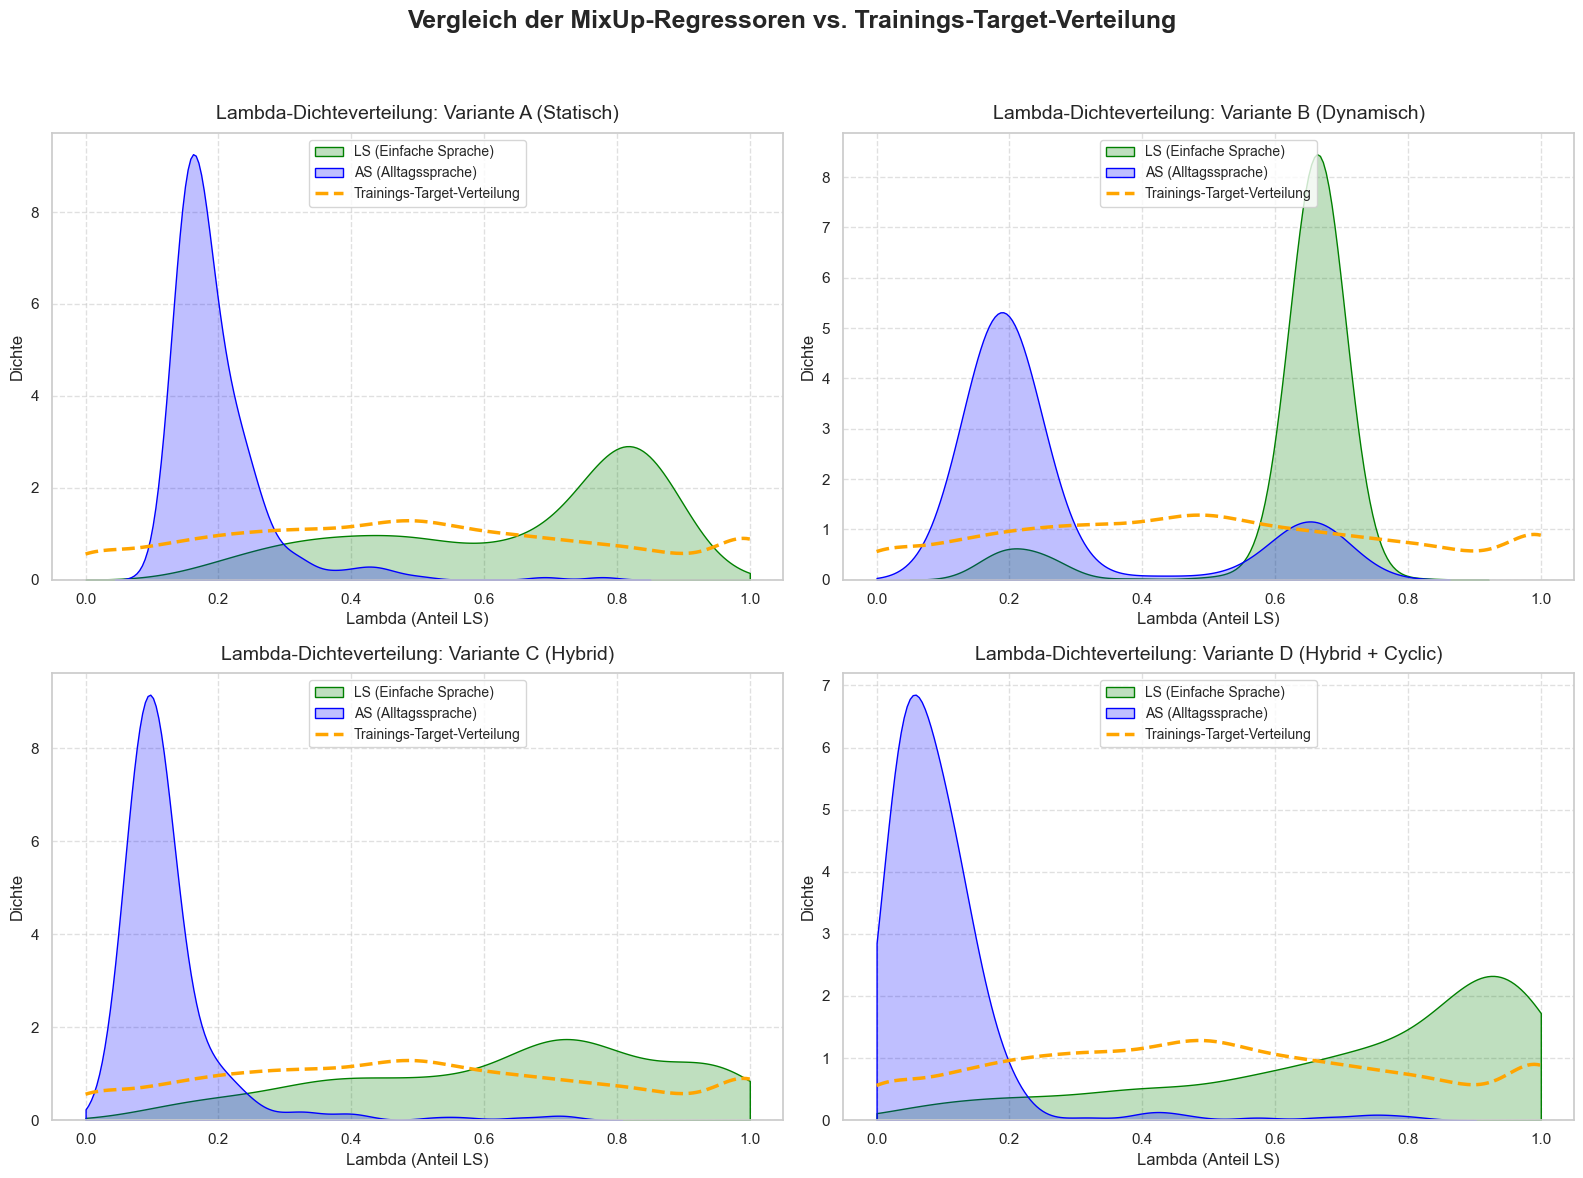

In [8]:
# 7. KDE-Plots (Dichteverteilungen) nebeneinander visualisieren
import pandas as pd
train_targets_path = "../results/train_targets_distribution.csv"
train_targets = pd.read_csv(train_targets_path)["target"]

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(results.keys()):
    ls_p = results[model_name]["ls_preds"]
    as_p = results[model_name]["as_preds"]
    
    # Plot model predictions
    sns.kdeplot(ls_p, fill=True, color="green", label="LS (Einfache Sprache)", ax=axes[i], clip=(0.0, 1.0))
    sns.kdeplot(as_p, fill=True, color="blue", label="AS (Alltagssprache)", ax=axes[i], clip=(0.0, 1.0))
    
    # Overlay the training target distribution
    sns.kdeplot(train_targets, fill=False, color="orange", linestyle="--", linewidth=2.5, label="Trainings-Target-Verteilung", ax=axes[i], clip=(0.0, 1.0))
    
    axes[i].set_title(f"Lambda-Dichteverteilung: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Lambda (Anteil LS)", fontsize=12)
    axes[i].set_ylabel("Dichte", fontsize=12)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren vs. Trainings-Target-Verteilung", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_distribution_with_targets.png", dpi=300)
plt.show()


# Evaluation auf dem zusätzlichen Test-Split

Wir evaluieren die vier trainierten MixUp-Regressoren auf dem ungesehenen Test-Split des parallel-ausgerichteten Datensatzes. Dies umfasst sowohl die binäre Klassifikation (Alltagssprache vs. Leichte Sprache) als auch die Regressionsevaluation (kontinuierliche Mischungen).

In [9]:
# 1. Binäre Klassifikationsevaluation auf dem Test-Split (LS = 1.0, AS = 0.0)
test_results = {}
for model_name, model in models.items():
    if model is None:
        continue
    test_results[model_name] = {"ls_preds": [], "as_preds": []}
    
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc=f"Test-Vorhersagen für {model_name}"):
        ls_text = str(row.get("ls_text", ""))
        as_text = str(row.get("as_text", ""))
        
        # LS (Einfache Sprache)
        ls_seqs = text_to_sequences(ls_text, vocab)
        if ls_seqs:
            tensors = torch.tensor(ls_seqs, dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                preds = model(tensors).squeeze().cpu().numpy()
                if preds.ndim == 0:
                    preds = np.array([preds])
                test_results[model_name]["ls_preds"].extend(preds)
                
        # AS (Alltagssprache)
        as_seqs = text_to_sequences(as_text, vocab)
        if as_seqs:
            tensors = torch.tensor(as_seqs, dtype=torch.long).to(DEVICE)
            with torch.no_grad():
                preds = model(tensors).squeeze().cpu().numpy()
                if preds.ndim == 0:
                    preds = np.array([preds])
                test_results[model_name]["as_preds"].extend(preds)


Test-Vorhersagen für Variante C (Hybrid): 100%|██████████| 104/104 [00:03<00:00, 31.76it/s]
Test-Vorhersagen für Variante D (Hybrid + Cyclic): 100%|██████████| 104/104 [00:03<00:00, 33.67it/s]


In [10]:
# 2. Klassifikationsmetriken auf dem Test-Split berechnen und anzeigen
test_table_rows = []
for model_name in test_results.keys():
    ls_p = test_results[model_name]["ls_preds"]
    as_p = test_results[model_name]["as_preds"]
    
    mean_ls = np.mean(ls_p)
    mean_as = np.mean(as_p)
    
    # Binäre Klassifikation mit Schwellenwert 0.5
    correct_ls = sum(1 for p in ls_p if p > 0.5)
    correct_as = sum(1 for p in as_p if p <= 0.5)
    
    acc = (correct_ls + correct_as) / (len(ls_p) + len(as_p))
    
    bacc_ls = correct_ls / len(ls_p)
    bacc_as = correct_as / len(as_p)
    bacc = (bacc_ls + bacc_as) / 2
    
    # MAE (LS-Abweichung von 1.0, AS-Abweichung von 0.0)
    mae = (sum(1.0 - p for p in ls_p) + sum(p for p in as_p)) / (len(ls_p) + len(as_p))
    
    test_table_rows.append({
        "Modell": model_name,
        "Ø Lambda (LS)": f"{mean_ls:.4f}",
        "Ø Lambda (AS)": f"{mean_as:.4f}",
        "Accuracy (Schwelle 0.5)": f"{acc*100:.2f}%",
        "Balanced Acc": f"{bacc*100:.2f}%",
        "MAE (Target 1/0)": f"{mae:.4f}"
    })
    
df_test_metrics = pd.DataFrame(test_table_rows)
import IPython.display as display
display.display(df_test_metrics)


,Modell,Ø Lambda (LS),Ø Lambda (AS),Accuracy (Schwelle 0.5),Balanced Acc,MAE (Target 1/0)
0,Variante A (Statisch),0.7596,0.2680,91.55%,91.46%,0.2526
1,Variante B (Dynamisch),0.6138,0.3312,80.17%,79.53%,0.3620
2,Variante C (Hybrid),0.8603,0.1657,95.04%,95.22%,0.1511
3,Variante D (Hybrid + Cyclic),0.9007,0.1382,95.92%,95.93%,0.1164


In [11]:
# 3. Dataset-Klasse für die Regressionsevaluation auf dem Test-Split definieren
from torch.utils.data import Dataset, DataLoader

class TestMixupDataset(Dataset):
    def __init__(self, df, vocab, nlp_sentencizer, max_seq_len=150, mixtures_per_pair=10):
        self.vocab = vocab
        self.max_seq_len = max_seq_len
        self.samples = []
        
        # Festgelegter Seed für Reproduzierbarkeit der Testmischungen
        random.seed(99)
        
        for _, row in df.iterrows():
            ls_doc = nlp_sentencizer(str(row["ls_text"]))
            as_doc = nlp_sentencizer(str(row["as_text"]))
            
            ls_sents = []
            for sent in ls_doc.sents:
                text = sent.text.strip()
                tokens = [t.text.lower() for t in sent if not t.is_space]
                if len(tokens) > 0:
                    ls_sents.append((tokens, len(text)))
                    
            as_sents = []
            for sent in as_doc.sents:
                text = sent.text.strip()
                tokens = [t.text.lower() for t in sent if not t.is_space]
                if len(tokens) > 0:
                    as_sents.append((tokens, len(text)))
                    
            num_leicht = len(ls_sents)
            num_alltag = len(as_sents)
            
            if num_leicht == 0 or num_alltag == 0:
                continue
                
            for _ in range(mixtures_per_pair):
                start_l, end_l = sorted([random.randint(0, num_leicht), random.randint(0, num_leicht)])
                sample_l = ls_sents[start_l:end_l]
                
                start_a, end_a = sorted([random.randint(0, num_alltag), random.randint(0, num_alltag)])
                sample_a = as_sents[start_a:end_a]
                
                if len(sample_l) == 0 and len(sample_a) == 0:
                    continue
                    
                char_len_l = sum(item[1] for item in sample_l)
                char_len_a = sum(item[1] for item in sample_a)
                total_char_len = char_len_l + char_len_a
                regression_target = char_len_l / total_char_len if total_char_len > 0 else 0.5
                
                mixed_sentences = [item[0] for item in sample_l] + [item[0] for item in sample_a]
                random.shuffle(mixed_sentences)
                
                flat_tokens = [token for sent in mixed_sentences for token in sent]
                encoded = self.vocab.encode(flat_tokens)
                
                if len(encoded) > self.max_seq_len:
                    encoded = encoded[:self.max_seq_len]
                else:
                    encoded = encoded + [0] * (self.max_seq_len - len(encoded))
                    
                self.samples.append((encoded, regression_target))
                
    def __len__(self):
        return len(self.samples)
        
    def __getitem__(self, idx):
        encoded, target = self.samples[idx]
        return torch.tensor(encoded, dtype=torch.long), torch.tensor(target, dtype=torch.float)

test_regression_dataset = TestMixupDataset(test_df, vocab, nlp, max_seq_len=150, mixtures_per_pair=10)
test_regression_loader = DataLoader(test_regression_dataset, batch_size=64, shuffle=False)
print(f"Anzahl gemischter Test-Regression Samples: {len(test_regression_dataset)}")


Anzahl gemischter Test-Regression Samples: 1037


In [12]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
# 4. Regressionsmetriken (MSE, MAE) auf dem Test-Split berechnen
test_reg_rows = []
for model_name, model in models.items():
    if model is None:
        continue
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_x, batch_y in test_regression_loader:
            batch_x = batch_x.to(DEVICE)
            preds = model(batch_x).squeeze()
            if preds.ndim == 0:
                preds = preds.unsqueeze(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.numpy())
            
    mse = mean_squared_error(all_targets, all_preds)
    mae = mean_absolute_error(all_targets, all_preds)
    
    test_reg_rows.append({
        "Modell": model_name,
        "Test MSE (Regression)": f"{mse:.4f}",
        "Test MAE (Regression)": f"{mae:.4f}"
    })
    
df_test_reg_metrics = pd.DataFrame(test_reg_rows)
display.display(df_test_reg_metrics)


,Modell,Test MSE (Regression),Test MAE (Regression)
0,Variante A (Statisch),0.0383,0.1557
1,Variante B (Dynamisch),0.0758,0.2264
2,Variante C (Hybrid),0.0267,0.1158
3,Variante D (Hybrid + Cyclic),0.0241,0.1027


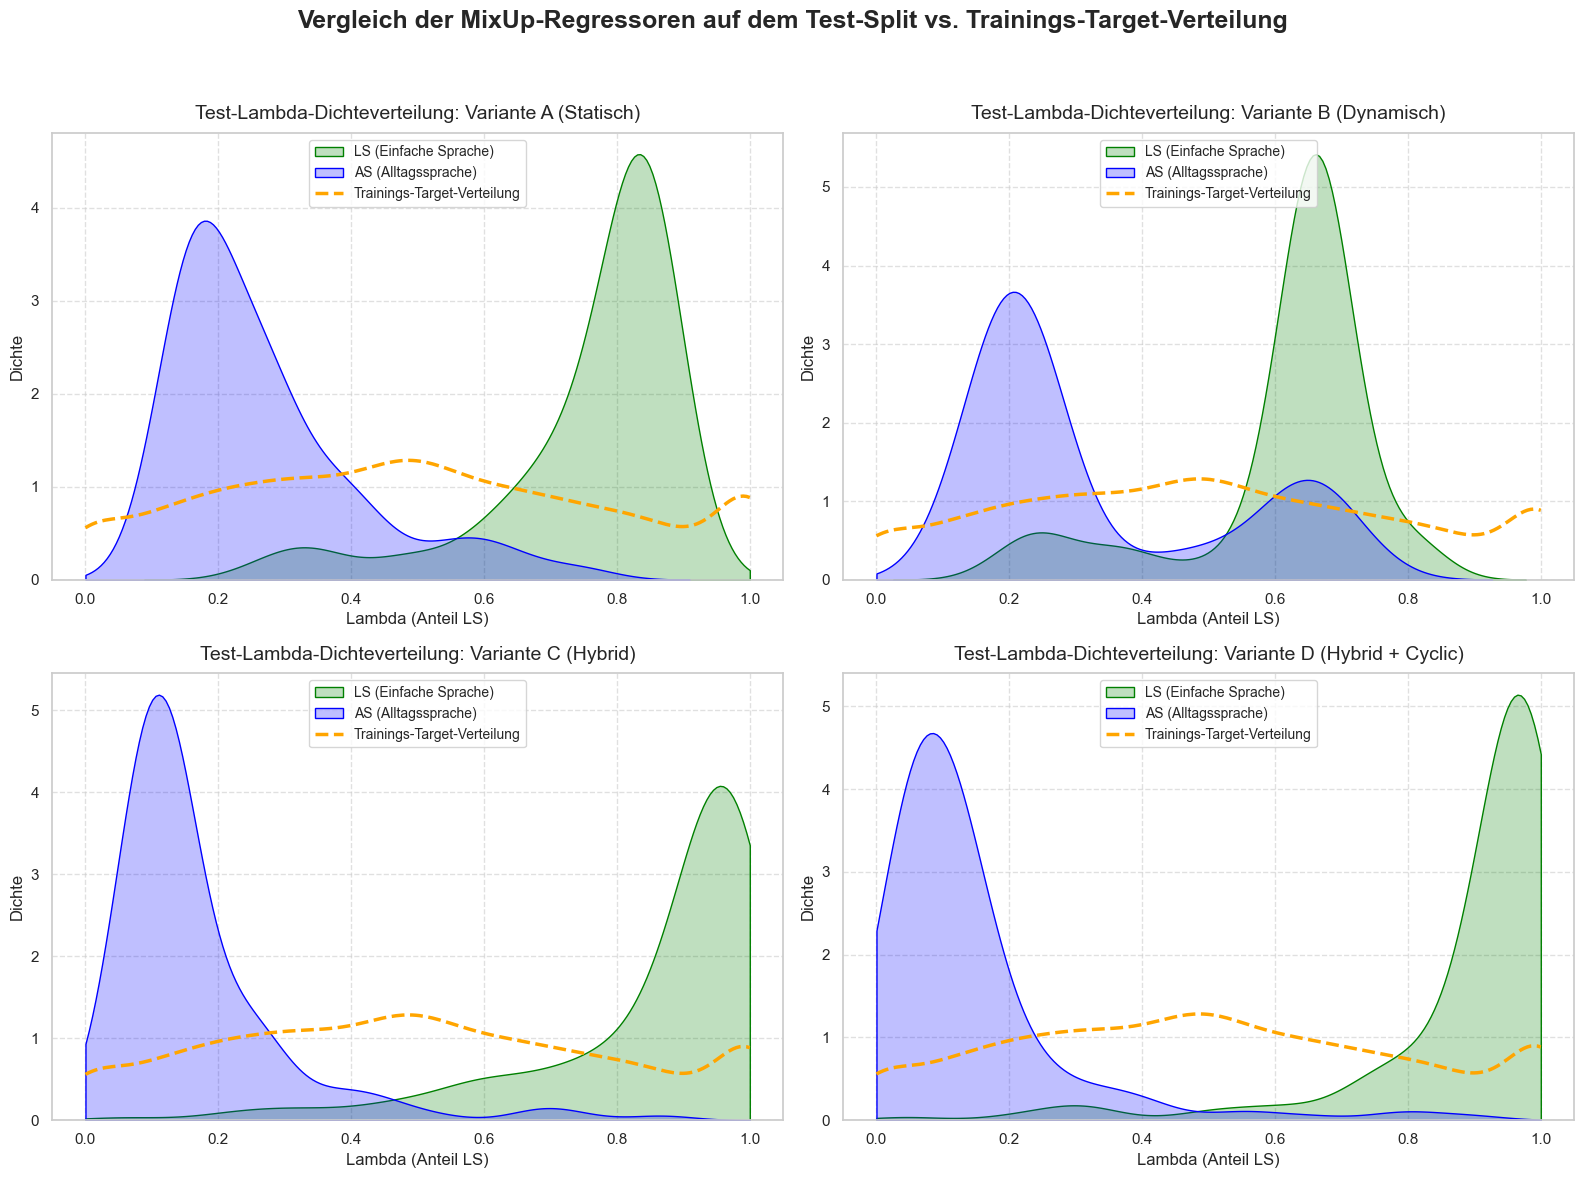

In [13]:
# Trainings-Targets laden für Visualisierung
train_targets_path = "../results/train_targets_distribution.csv"
if os.path.exists(train_targets_path):
    train_targets = pd.read_csv(train_targets_path)["target"]
else:
    train_targets = None

# 5. KDE-Plots (Dichteverteilungen) für den Test-Split visualisieren
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(test_results.keys()):
    ls_p = test_results[model_name]["ls_preds"]
    as_p = test_results[model_name]["as_preds"]
    
    # Model-Vorhersagen plotten
    sns.kdeplot(ls_p, fill=True, color="green", label="LS (Einfache Sprache)", ax=axes[i], clip=(0.0, 1.0))
    sns.kdeplot(as_p, fill=True, color="blue", label="AS (Alltagssprache)", ax=axes[i], clip=(0.0, 1.0))
    
    # Trainings-Target-Verteilung überlagern
    if train_targets is not None:
        sns.kdeplot(train_targets, fill=False, color="orange", linestyle="--", linewidth=2.5, label="Trainings-Target-Verteilung", ax=axes[i], clip=(0.0, 1.0))
    
    axes[i].set_title(f"Test-Lambda-Dichteverteilung: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Lambda (Anteil LS)", fontsize=12)
    axes[i].set_ylabel("Dichte", fontsize=12)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren auf dem Test-Split vs. Trainings-Target-Verteilung", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("../results/mixup_test_distribution_with_targets.png", dpi=300)
plt.show()


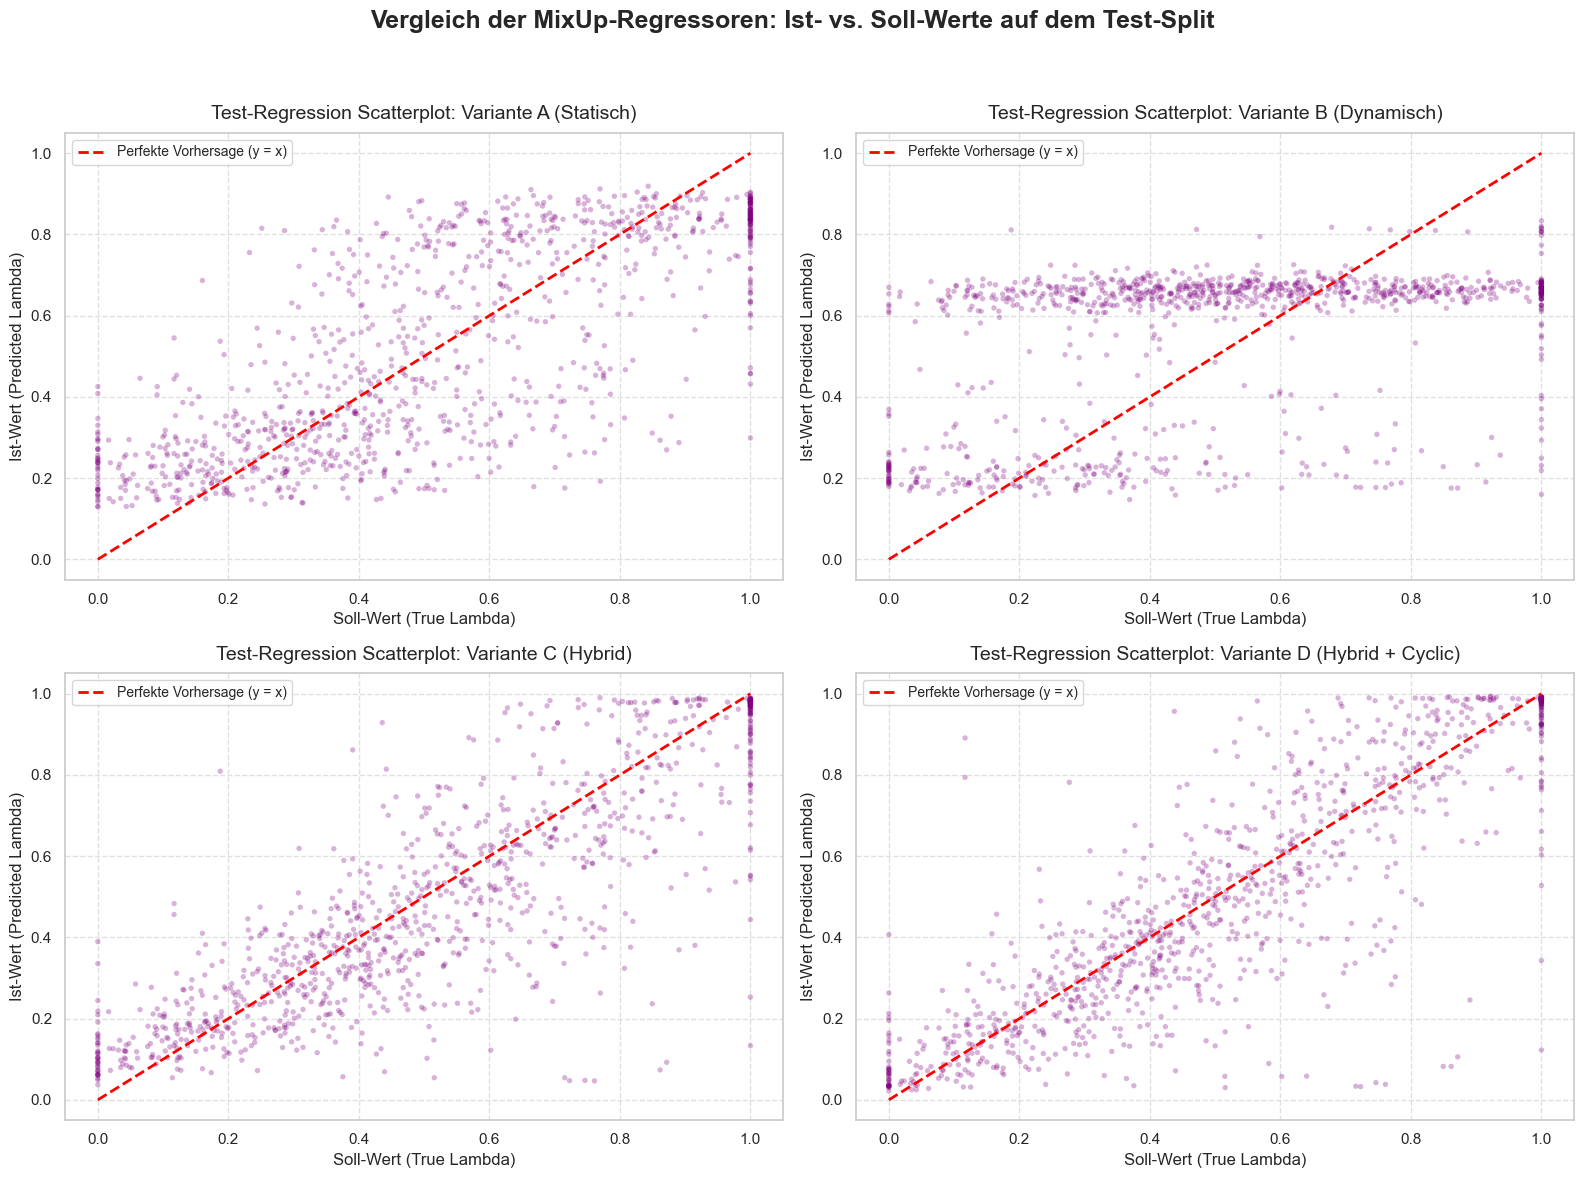

In [14]:
# 6. Scatterplots (Ist- vs. Soll-Wert) für die Regression auf dem Test-Split visualisieren
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(models.keys()):
    if models[model_name] is None:
        continue
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_x, batch_y in test_regression_loader:
            batch_x = batch_x.to(DEVICE)
            preds = models[model_name](batch_x).squeeze()
            if preds.ndim == 0:
                preds = preds.unsqueeze(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.numpy())
            
    # Scatter plot
    axes[i].scatter(all_targets, all_preds, alpha=0.3, color="purple", edgecolors='none', s=15)
    
    # Perfekte Vorhersagelinie (y = x)
    axes[i].plot([0, 1], [0, 1], color="red", linestyle="--", linewidth=2, label="Perfekte Vorhersage (y = x)")
    
    axes[i].set_title(f"Test-Regression Scatterplot: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Soll-Wert (True Lambda)", fontsize=12)
    axes[i].set_ylabel("Ist-Wert (Predicted Lambda)", fontsize=12)
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].set_ylim(-0.05, 1.05)
    axes[i].legend(fontsize=10, loc="upper left")
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Ist- vs. Soll-Werte auf dem Test-Split", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
reg_plot_path = "../results/mixup_test_regression_scatterplot.png"
plt.savefig(reg_plot_path, dpi=300)
plt.show()


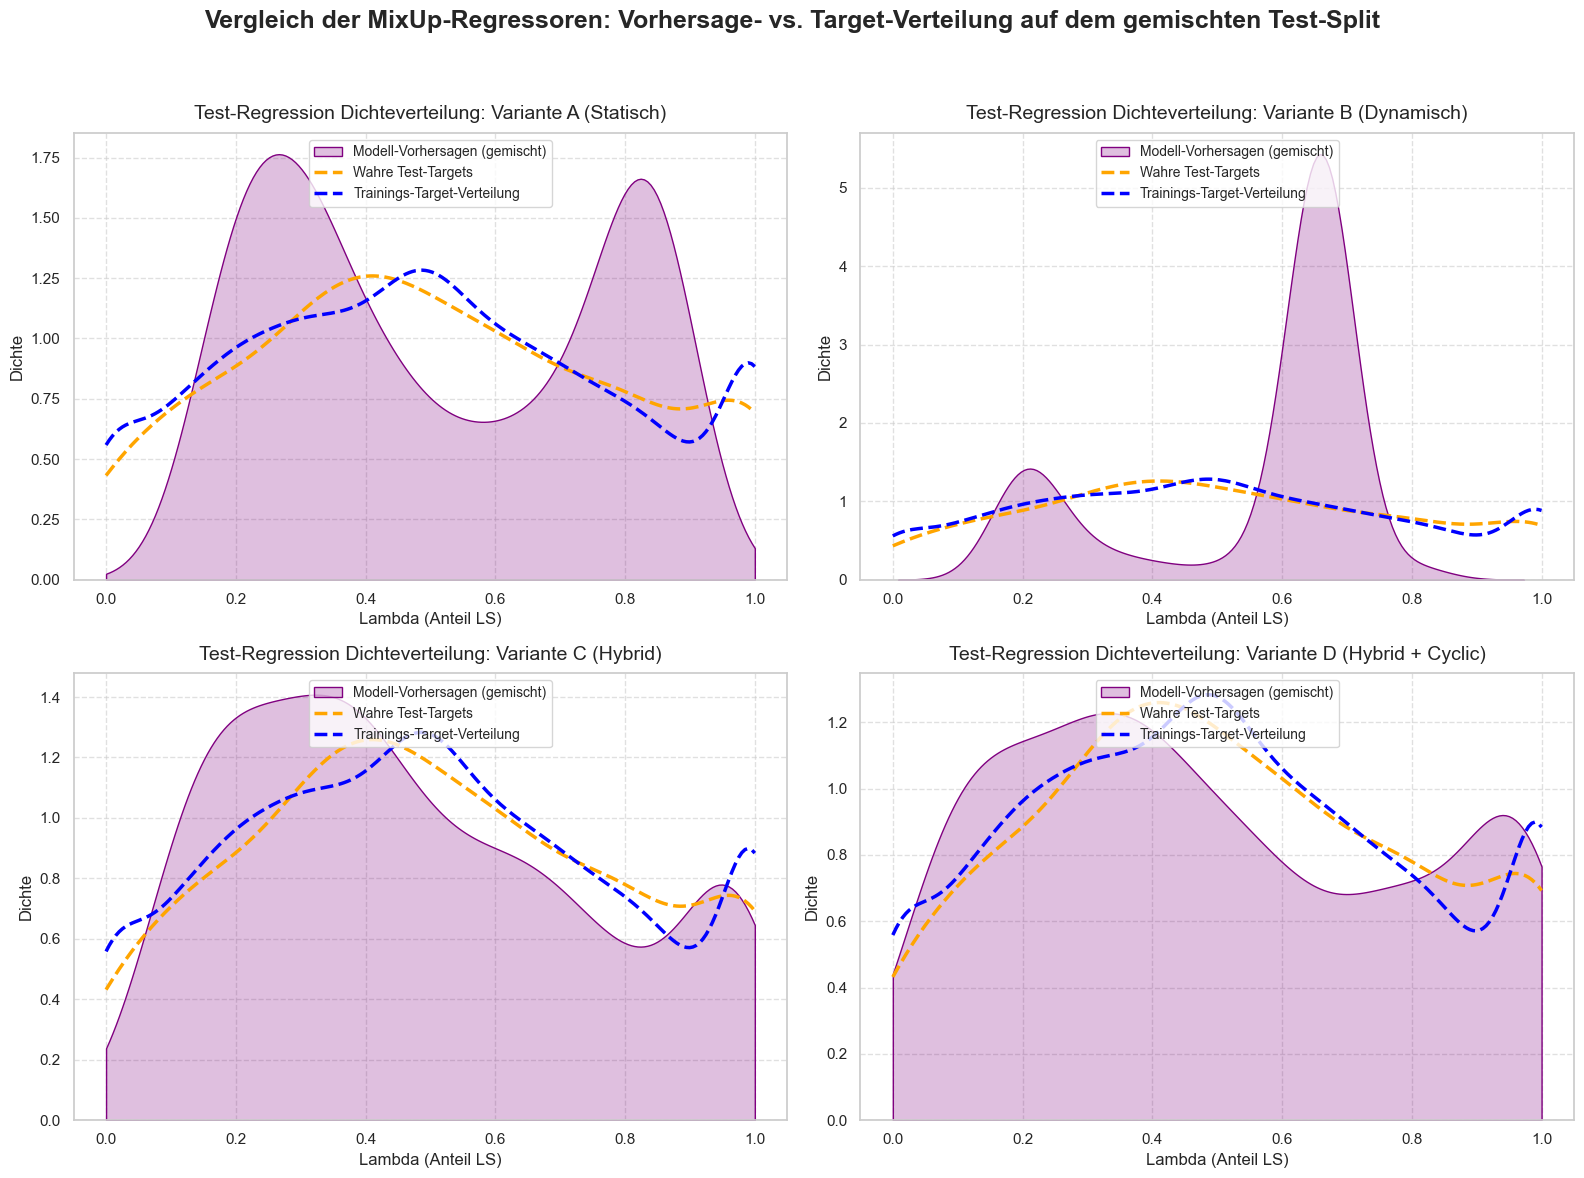

In [17]:
# 7. KDE-Plots (Dichteverteilungen) für die gemischte (MixUp) Regression auf dem Test-Split visualisieren
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.ravel()

for i, model_name in enumerate(models.keys()):
    if models[model_name] is None:
        continue
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for batch_x, batch_y in test_regression_loader:
            batch_x = batch_x.to(DEVICE)
            preds = models[model_name](batch_x).squeeze()
            if preds.ndim == 0:
                preds = preds.unsqueeze(0)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch_y.numpy())
            
    # Vorhersage-Verteilung plotten (lila)
    sns.kdeplot(all_preds, fill=True, color="purple", label="Modell-Vorhersagen (gemischt)", ax=axes[i], clip=(0.0, 1.0))
    
    # Wahre Test-Targets überlagern (orange gestrichelt)
    sns.kdeplot(all_targets, fill=False, color="orange", linestyle="--", linewidth=2.5, label="Wahre Test-Targets", ax=axes[i], clip=(0.0, 1.0))


     # Trainings-Target-Verteilung überlagern
    if train_targets is not None:
        sns.kdeplot(train_targets, fill=False, color="blue", linestyle="--", linewidth=2.5, label="Trainings-Target-Verteilung", ax=axes[i], clip=(0.0, 1.0))
    
    
    axes[i].set_title(f"Test-Regression Dichteverteilung: {model_name}", fontsize=14, pad=10)
    axes[i].set_xlabel("Lambda (Anteil LS)", fontsize=12)
    axes[i].set_ylabel("Dichte", fontsize=12)
    axes[i].legend(fontsize=10, loc="upper center")
    axes[i].set_xlim(-0.05, 1.05)
    axes[i].grid(True, linestyle="--", alpha=0.6)

plt.suptitle("Vergleich der MixUp-Regressoren: Vorhersage- vs. Target-Verteilung auf dem gemischten Test-Split", fontsize=18, weight="bold", y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
reg_kde_plot_path = "../results/mixup_test_regression_kde.png"
plt.savefig(reg_kde_plot_path, dpi=300)
plt.show()
